In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [3]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(url)

In [5]:
df["credit_risk"].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

In [7]:
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [11]:
df = pd.get_dummies(df, drop_first=True)
df

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk,status_... >= 200 DM / salary for at least 1 year,status_0 <= ... < 200 DM,...,property_unknown/no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/official,job_unemployed/unskilled - non-resident,job_unskilled - resident,telephone_yes,foreign_worker_yes
0,6,1169,4,4,67,2,1,1,False,False,...,False,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,0,False,True,...,False,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,1,False,False,...,False,True,False,True,False,False,False,True,False,True
3,42,7882,2,4,45,1,2,1,False,False,...,False,True,False,False,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,0,False,False,...,True,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,1,False,False,...,False,True,False,True,False,False,False,True,False,True
996,30,3857,4,4,40,1,1,1,False,False,...,False,True,False,True,False,False,False,False,True,True
997,12,804,4,4,38,1,1,1,False,False,...,False,True,False,True,False,True,False,False,False,True
998,45,1845,4,4,23,1,1,0,False,False,...,True,True,False,False,False,True,False,False,True,True


In [13]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

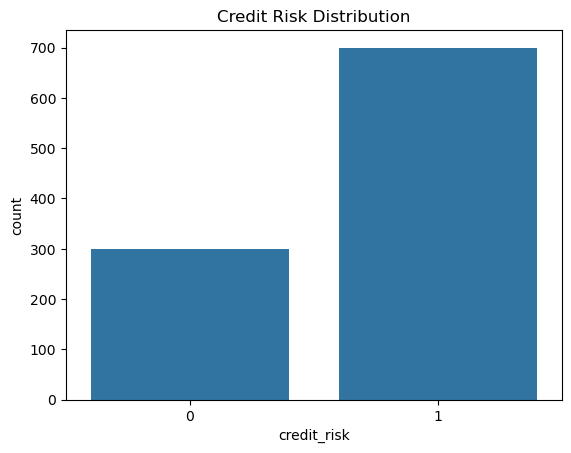

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

sns.countplot(x=y)
plt.title("Credit Risk Distribution")
plt.show()

In [33]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

y_pred_custom = (y_prob_log > 0.6).astype(int)

In [45]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_custom = (y_prob_log > 0.6).astype(int)

In [47]:
def evaluate(y_test, y_pred, y_prob):
    print("Custom Threshold (0.6) Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

evaluate(y_test, y_pred_log, y_prob_log)
evaluate(y_test, y_pred_rf, y_prob_rf)

Custom Threshold (0.6) Results:
Accuracy: 0.805
ROC-AUC: 0.8177665584805865

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.59      0.64        59
           1       0.84      0.89      0.87       141

    accuracy                           0.81       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.80      0.81      0.80       200


Confusion Matrix:
 [[ 35  24]
 [ 15 126]]
Custom Threshold (0.6) Results:
Accuracy: 0.765
ROC-AUC: 0.8094121889650199

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.41      0.51        59
           1       0.79      0.91      0.85       141

    accuracy                           0.77       200
   macro avg       0.73      0.66      0.68       200
weighted avg       0.75      0.77      0.75       200


Confusion Matrix:
 [[ 24  35]
 [ 12 129]]


In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": log_model.coef_[0]
}).sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
9,status_no checking account,0.779592
10,credit_history_critical account/other credits ...,0.614802
4,age,0.322607
39,other_installment_plans_none,0.290778
26,savings_unknown/no savings account,0.266388
11,credit_history_delay in paying off in the past,0.264661
12,credit_history_existing credits paid back duly...,0.254010
33,personal_status_sex_male : single,0.253371
7,status_... >= 200 DM / salary for at least 1 year,0.251524
34,other_debtors_guarantor,0.216719


In [51]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_rf.head(10)

,Feature,Importance
1,amount,0.113233
4,age,0.102397
0,duration,0.084973
9,status_no checking account,0.063487
2,installment_rate,0.040281
3,present_residence,0.040161
39,other_installment_plans_none,0.022572
14,purpose_car (new),0.022418
10,credit_history_critical account/other credits ...,0.021986
5,number_credits,0.021596


In [ ]:
## Model Evaluation and Interpretation

The Logistic Regression model achieved an accuracy of approximately 80.5% and an ROC-AUC score of 0.82, indicating good overall predictive performance.

However, accuracy alone is not sufficient in a credit risk context. The confusion matrix shows that 24 high-risk customers (defaulters) were incorrectly classified as low-risk and would have been approved for loans.

This type of error (false negatives) is particularly costly in banking, as it can lead to financial losses due to loan defaults.

On the positive side, the model correctly identified 126 low-risk customers, demonstrating strong ability to approve reliable applicants.

In [ ]:
## Business Insight

In a real-world banking scenario, minimizing the approval of high-risk customers is more important than maximizing overall accuracy.

Although the model performs well statistically, it still allows a significant number of risky customers to be approved.

To address this, the decision threshold was increased from 0.5 to 0.6, making the model more conservative in approving loans.

This adjustment reduces risk exposure but may also result in rejecting some good customers, highlighting the trade-off between risk and customer approval rates.